# SQLStorm — query-corpus frequency analysis and run outcomes

Two things are pulled from the server and joined here:

1. the **17,036 SQLStorm query files** from `queries/tpch/SQLStorm/` (the SQL *text*), and
2. the **run log** `logs/sqlstorm/` (one single-copy measured batch per query at a 2.5 GHz
   clock cap and a **15 s statement timeout**), which carries per-query runtime, energy and
   the `failed` flag.

The queries are cached under **`cache/sqlstorm_cache/queries/`** (git-ignored — 17k files) and the
logs under `cache/sqlstorm_cache/logs/`. From the text we build a per-query **feature table**
(clauses, joins, tables, functions, size) and report how often each construct appears; from
the log we report the runtime/energy distribution and the **failure vs timeout** split, then
cross the two. Deliverables written to the repo root:

* `csv/sqlstorm_query_features.csv` — one row per query with all extracted features;
* `csv/sqlstorm_failed_queries.csv` — every query with `failed=1` (timeout **or** error);
* `csv/sqlstorm_timeout_queries.csv` — the timeout subset only.

One claim per figure; units on every axis.

## 0. Pull the query corpus and the run log → `cache/sqlstorm_cache/`

The 17k `.sql` files are streamed as a single **tarball** over SSH (`tar -cf -`), which is far
faster than 17,000 SFTP round-trips, and extracted into `cache/sqlstorm_cache/queries/`. The three
log CSVs are copied into `cache/sqlstorm_cache/logs/`. Both **fall back to the local cache** if the
server is unreachable; set `REFRESH = True` to force a re-pull even when the cache is full.

In [1]:
# %pip install paramiko pandas matplotlib
import io, re, tarfile, time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd

SSH_HOST = "192.168.1.42"
SSH_USER = "user01"
SSH_PASS = "a"                                   # demo credential
REMOTE_ROOT = "/home/user01/GreenSQL"
REMOTE_QDIR = f"{REMOTE_ROOT}/queries/tpch/SQLStorm"
REMOTE_LOG  = f"{REMOTE_ROOT}/logs/sqlstorm"
LOG_FILES   = ["query_timing_tpch_idx.csv", "query_samples_tpch_idx.csv",
               "query_catalog_tpch_idx.csv"]

CACHE   = Path("cache/sqlstorm_cache")
QCACHE  = CACHE / "queries"                      # 17k .sql files (git-ignored)
LCACHE  = CACHE / "logs"
QCACHE.mkdir(parents=True, exist_ok=True); LCACHE.mkdir(parents=True, exist_ok=True)
EXPECT_Q = 17036
REFRESH  = False                                 # True forces a re-pull from the server


def _ssh():
    import paramiko
    cl = paramiko.SSHClient()
    cl.set_missing_host_key_policy(paramiko.AutoAddPolicy())
    cl.connect(SSH_HOST, username=SSH_USER, password=SSH_PASS,
               timeout=45, banner_timeout=45, auth_timeout=45)
    return cl


def pull_queries():
    have = len(list(QCACHE.glob("*.sql")))
    if have >= EXPECT_Q and not REFRESH:
        print(f"queries: using cache ({have} .sql files; set REFRESH=True to re-pull)")
        return "cache"
    try:
        cl = _ssh()
        try:
            _, out, err = cl.exec_command(f"tar -C {REMOTE_QDIR} -cf - .")
            data = out.read(); errtxt = err.read().decode("utf-8", "replace")
            if not data:
                raise RuntimeError(f"empty tar stream ({errtxt[:120]})")
            n = 0
            with tarfile.open(fileobj=io.BytesIO(data)) as tf:
                for m in tf.getmembers():
                    if m.isfile() and m.name.endswith(".sql"):
                        (QCACHE / Path(m.name).name).write_bytes(tf.extractfile(m).read())
                        n += 1
            print(f"queries: pulled {n} .sql files ({len(data)/1e6:.1f} MB tar) -> {QCACHE}/")
            return "server"
        finally:
            cl.close()
    except Exception as exc:
        have = len(list(QCACHE.glob("*.sql")))
        if have == 0:
            raise RuntimeError(f"{exc}\nNo query cache at '{QCACHE}/'.") from exc
        print(f"!! query pull failed ({exc}); falling back to cache ({have} files).")
        return "cache"


def pull_logs():
    try:
        cl = _ssh()
        try:
            with cl.open_sftp() as sftp:
                got = []
                for fn in LOG_FILES:
                    try:
                        (LCACHE / fn).write_bytes(sftp.open(f"{REMOTE_LOG}/{fn}").read())
                        got.append(fn)
                    except Exception:
                        pass
            print(f"logs: pulled {got} -> {LCACHE}/")
            return "server"
        finally:
            cl.close()
    except Exception as exc:
        have = [p.name for p in LCACHE.glob("*.csv")]
        if not have:
            raise RuntimeError(f"{exc}\nNo log cache at '{LCACHE}/'.") from exc
        print(f"!! log pull failed ({exc}); falling back to cache ({have}).")
        return "cache"


QSRC = pull_queries()
LSRC = pull_logs()
QFILES = sorted(QCACHE.glob("*.sql"))
print(f"\nsources: queries={QSRC}, logs={LSRC};  {len(QFILES)} query files cached")

queries: using cache (17036 .sql files; set REFRESH=True to re-pull)


logs: pulled ['query_timing_tpch_idx.csv', 'query_samples_tpch_idx.csv', 'query_catalog_tpch_idx.csv'] -> cache\sqlstorm_cache\logs/

sources: queries=cache, logs=server;  17036 query files cached


## 1. Parse every query into a feature table

Each file starts with a `--` header line and an `EXPLAIN (ANALYZE …)` wrapper added by the
harness; both are stripped before analysis (comments removed, the leading `EXPLAIN (...)`
clause dropped) so we measure the *query*, not the wrapper. From the cleaned text we extract,
per query: the statement shape (CTE vs plain), presence of the major clauses, join count and
join kinds, the set of TPC-H tables referenced, common SQL functions, and size (characters,
lines, tokens, `SELECT` count as a subquery-depth proxy).

In [2]:
TPCH_TABLES = ["lineitem", "orders", "customer", "part", "partsupp",
               "supplier", "nation", "region"]
AGGS   = ["count", "sum", "avg", "min", "max", "string_agg", "array_agg"]
STRFUN = ["substring", "concat", "replace", "upper", "lower", "trim", "coalesce",
          "cast", "round", "extract", "date_trunc", "case"]

EXPLAIN_RE = re.compile(r"^\s*EXPLAIN\s*\([^)]*\)\s*", re.I)
LINE_COMMENT = re.compile(r"--[^\n]*")
BLOCK_COMMENT = re.compile(r"/\*.*?\*/", re.S)


def clean_sql(txt):
    t = BLOCK_COMMENT.sub(" ", LINE_COMMENT.sub(" ", txt))
    t = EXPLAIN_RE.sub("", t)
    return t


def wc(pat, U):
    return len(re.findall(pat, U))


def features(txt):
    raw_lines = txt.count("\n") + 1
    t = clean_sql(txt)
    U = t.upper()
    n_select = wc(r"\bSELECT\b", U)
    f = dict(
        chars=len(t.strip()), lines=raw_lines, tokens=wc(r"\w+", t),
        n_select=n_select, n_join=wc(r"\bJOIN\b", U),
        n_where=wc(r"\bWHERE\b", U), n_cte=wc(r"\bWITH\b|\)\s*,\s*\w+\s+AS\s*\(", U),
        is_cte=bool(re.match(r"\s*WITH\b", U)),
        has_where=bool(re.search(r"\bWHERE\b", U)),
        has_join=bool(re.search(r"\bJOIN\b", U)),
        has_group=bool(re.search(r"\bGROUP\s+BY\b", U)),
        has_having=bool(re.search(r"\bHAVING\b", U)),
        has_order=bool(re.search(r"\bORDER\s+BY\b", U)),
        has_limit=bool(re.search(r"\bLIMIT\b", U)),
        has_distinct=bool(re.search(r"\bDISTINCT\b", U)),
        has_case=bool(re.search(r"\bCASE\b", U)),
        has_window=bool(re.search(r"\bOVER\s*\(", U)),
        has_union=bool(re.search(r"\bUNION\b|\bINTERSECT\b|\bEXCEPT\b", U)),
        has_exists=bool(re.search(r"\bEXISTS\b", U)),
        has_in_subq=bool(re.search(r"\bIN\s*\(\s*SELECT\b", U)),
        has_like=bool(re.search(r"\bLIKE\b|\bILIKE\b", U)),
        has_subquery=n_select > 1,
    )
    for jt in ["inner", "left", "right", "full", "cross"]:
        f[f"join_{jt}"] = bool(re.search(rf"\b{jt.upper()}\s+(OUTER\s+)?JOIN\b", U))
    tbls = [tb for tb in TPCH_TABLES if re.search(rf"\b{tb.upper()}\b", U)]
    f["n_tables"] = len(tbls)
    for tb in TPCH_TABLES:
        f[f"tbl_{tb}"] = bool(re.search(rf"\b{tb.upper()}\b", U))
    for fn in AGGS + STRFUN:
        f[f"fn_{fn}"] = bool(re.search(rf"\b{fn.upper()}\s*\(", U))
    return f


rows = []
for p in QFILES:
    fe = features(p.read_text(encoding="utf-8", errors="replace"))
    fe["qid"] = p.stem                          # e.g. "29732"
    fe["query"] = f"queries/tpch/SQLStorm/{p.name}"
    rows.append(fe)
FEAT = pd.DataFrame(rows).set_index("qid")
FEAT.to_csv("csv/sqlstorm_query_features.csv")
print(f"feature table: {FEAT.shape[0]} queries x {FEAT.shape[1]} features "
      f"-> csv/sqlstorm_query_features.csv\n")
print(FEAT[["chars", "lines", "tokens", "n_select", "n_join", "n_tables",
            "is_cte", "has_window"]].head(6).to_string())

feature table: 17036 queries x 56 features -> csv/sqlstorm_query_features.csv

       chars  lines  tokens  n_select  n_join  n_tables  is_cte  has_window
qid                                                                        
100     1354     64     161         5       5         5    True        True
10001    456     25      68         1       5         6   False       False
10002    548     28      84         1       5         6   False       False
10003    451     23      69         1       5         6   False       False
10004    401     21      54         1       2         3   False       False
10005    395     22      55         1       2         3   False       False


## 2. How often each SQL construct appears

Share of the 17k queries that contain each clause / construct. This characterises the corpus:
how many are simple single-table `SELECT`s vs multi-join analytic queries with CTEs, windows,
set operations, and so on.

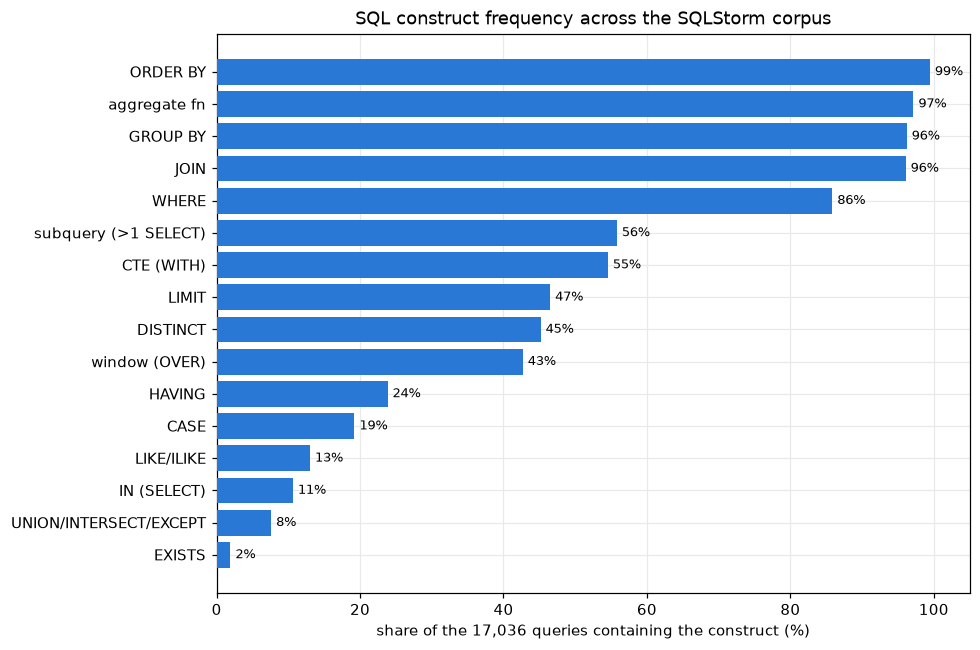

Construct frequency (%):
  ORDER BY                  99.5%
  aggregate fn              97.2%
  GROUP BY                  96.2%
  JOIN                      96.1%
  WHERE                     85.8%
  subquery (>1 SELECT)      55.8%
  CTE (WITH)                54.5%
  LIMIT                     46.5%
  DISTINCT                  45.2%
  window (OVER)             42.7%
  HAVING                    23.8%
  CASE                      19.2%
  LIKE/ILIKE                13.0%
  IN (SELECT)               10.6%
  UNION/INTERSECT/EXCEPT     7.6%
  EXISTS                     1.9%


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "savefig.facecolor": "white", "axes.grid": True,
                     "grid.color": "#e9e9e9", "axes.axisbelow": True,
                     "font.size": 9.5, "figure.dpi": 110})
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
N = len(FEAT)

constructs = [
    ("JOIN", "has_join"), ("WHERE", "has_where"), ("GROUP BY", "has_group"),
    ("ORDER BY", "has_order"), ("aggregate fn", None), ("subquery (>1 SELECT)", "has_subquery"),
    ("DISTINCT", "has_distinct"), ("CTE (WITH)", "is_cte"), ("CASE", "has_case"),
    ("HAVING", "has_having"), ("LIMIT", "has_limit"), ("window (OVER)", "has_window"),
    ("LIKE/ILIKE", "has_like"), ("UNION/INTERSECT/EXCEPT", "has_union"),
    ("EXISTS", "has_exists"), ("IN (SELECT)", "has_in_subq"),
]
agg_any = FEAT[[f"fn_{a}" for a in AGGS]].any(axis=1)
vals = []
for lbl, col in constructs:
    share = 100 * (agg_any.mean() if col is None else FEAT[col].mean())
    vals.append((lbl, share))
vals.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(vals))
ax.barh(y, [v for _, v in vals], color="#2a78d6", zorder=3)
for i, (_, v) in enumerate(vals):
    ax.text(v + 0.7, i, f"{v:.0f}%", va="center", fontsize=8.5)
ax.set_yticks(y); ax.set_yticklabels([l for l, _ in vals])
ax.set_xlabel("share of the 17,036 queries containing the construct (%)")
ax.set_xlim(0, 105)
ax.set_title("SQL construct frequency across the SQLStorm corpus", fontsize=11.5)
fig.tight_layout(); fig.savefig(FIG / "sqlstorm_construct_freq.svg", bbox_inches="tight")
plt.show()
print("Construct frequency (%):")
for lbl, v in sorted(vals, key=lambda x: -x[1]):
    print(f"  {lbl:24} {v:5.1f}%")

## 3. Structural complexity distributions

How heavy the queries are structurally: number of joins, number of distinct TPC-H tables
touched, and raw size in tokens. These are the axes we later relate to runtime and timeouts.

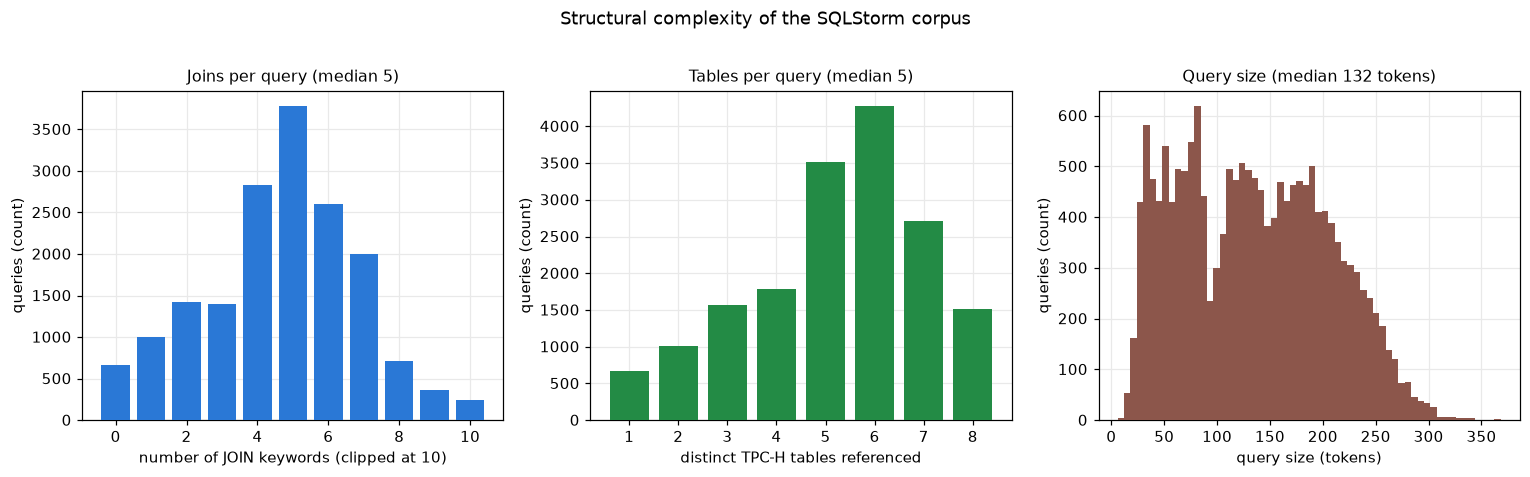

        n_join  n_tables   tokens  n_select    chars    lines
count  17036.0   17036.0  17036.0   17036.0  17036.0  17036.0
mean       4.7       5.2    134.9       3.2   1054.3     41.6
std        2.2       1.8     69.7       2.3    580.9     20.4
min        0.0       1.0      6.0       1.0     41.0      5.0
50%        5.0       5.0    132.0       3.0   1036.0     38.0
90%        7.0       7.0    231.0       6.0   1828.0     70.0
99%       10.0       8.0    285.0       9.0   2284.7     89.0
max       18.0       8.0    368.0      14.0   3122.0    119.0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
# joins
jc = FEAT["n_join"].clip(upper=10).value_counts().sort_index()
axes[0].bar(jc.index, jc.values, color="#2a78d6", zorder=3)
axes[0].set_xlabel("number of JOIN keywords (clipped at 10)")
axes[0].set_ylabel("queries (count)")
axes[0].set_title(f"Joins per query (median {int(FEAT['n_join'].median())})", fontsize=10.5)
# tables
tc = FEAT["n_tables"].value_counts().sort_index()
axes[1].bar(tc.index, tc.values, color="#238b45", zorder=3)
axes[1].set_xlabel("distinct TPC-H tables referenced")
axes[1].set_ylabel("queries (count)")
axes[1].set_title(f"Tables per query (median {int(FEAT['n_tables'].median())})", fontsize=10.5)
# tokens
axes[2].hist(FEAT["tokens"], bins=60, color="#8c564b", zorder=3)
axes[2].set_xlabel("query size (tokens)")
axes[2].set_ylabel("queries (count)")
axes[2].set_title(f"Query size (median {int(FEAT['tokens'].median())} tokens)", fontsize=10.5)
fig.suptitle("Structural complexity of the SQLStorm corpus", fontsize=12, y=1.02)
fig.tight_layout(); fig.savefig(FIG / "sqlstorm_complexity.svg", bbox_inches="tight")
plt.show()
print(FEAT[["n_join", "n_tables", "tokens", "n_select", "chars", "lines"]]
      .describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())

## 4. Which TPC-H tables the corpus leans on

Share of queries referencing each of the eight TPC-H tables. The fact-style tables
(`lineitem`, `orders`) should dominate; the small dimension tables less so.

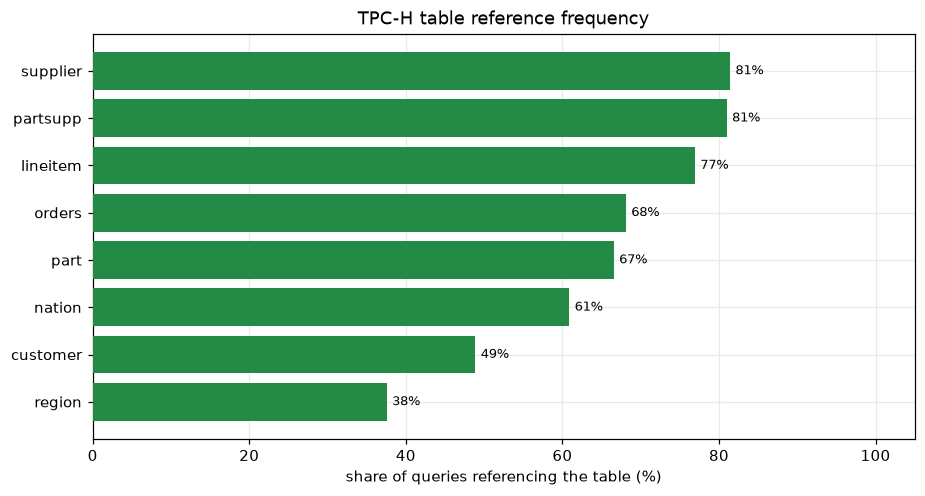

In [5]:
tv = [(tb, 100 * FEAT[f"tbl_{tb}"].mean()) for tb in TPCH_TABLES]
tv.sort(key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(8.5, 4.6))
y = np.arange(len(tv))
ax.barh(y, [v for _, v in tv], color="#238b45", zorder=3)
for i, (_, v) in enumerate(tv):
    ax.text(v + 0.7, i, f"{v:.0f}%", va="center", fontsize=8.5)
ax.set_yticks(y); ax.set_yticklabels([t for t, _ in tv])
ax.set_xlabel("share of queries referencing the table (%)")
ax.set_xlim(0, 105)
ax.set_title("TPC-H table reference frequency", fontsize=11.5)
fig.tight_layout(); fig.savefig(FIG / "sqlstorm_table_freq.svg", bbox_inches="tight")
plt.show()

## 5. SQL function usage

Share of queries calling each aggregate and scalar/string/date function. Shows how much the
corpus exercises beyond plain relational algebra (string manipulation, `CASE`, windows, casts).

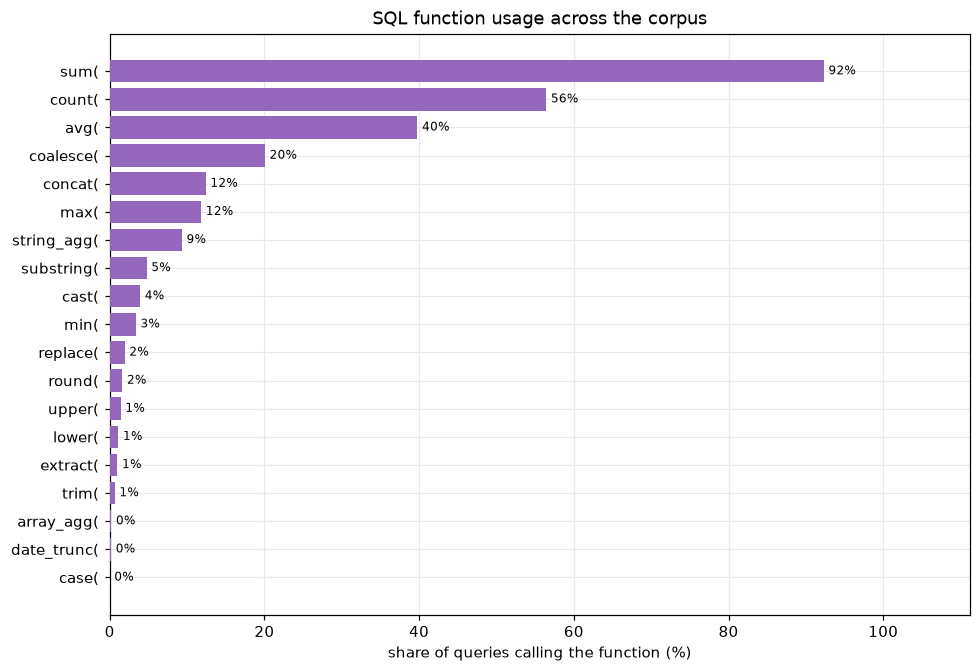

In [6]:
funcs = AGGS + STRFUN
fv = [(fn, 100 * FEAT[f"fn_{fn}"].mean()) for fn in funcs]
fv.sort(key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(9, 6.2))
y = np.arange(len(fv))
ax.barh(y, [v for _, v in fv], color="#9467bd", zorder=3)
for i, (_, v) in enumerate(fv):
    ax.text(v + 0.6, i, f"{v:.0f}%", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels([f + "(" for f, _ in fv])
ax.set_xlabel("share of queries calling the function (%)")
ax.set_xlim(0, max(v for _, v in fv) * 1.15 + 5)
ax.set_title("SQL function usage across the corpus", fontsize=11.5)
fig.tight_layout(); fig.savefig(FIG / "sqlstorm_function_freq.svg", bbox_inches="tight")
plt.show()

## 6. Run outcomes — runtime, energy, and the failure/timeout split

From `logs/sqlstorm/`. A row is `failed=1` when the query errored **or** hit the **15 s
statement timeout**. We separate the two by elapsed time: a failure whose `elapsed_sec` is at
the timeout ceiling (`≥ TIMEOUT_S`) is a **timeout**; anything shorter is a genuine **error**
(syntax, unsupported construct, missing object, …). Passing queries get the runtime/energy
distributions.

measured queries: 17036
  ok        14380  (84.4%)
  timeout    2309  (13.6%)
  error       347  (2.0%)


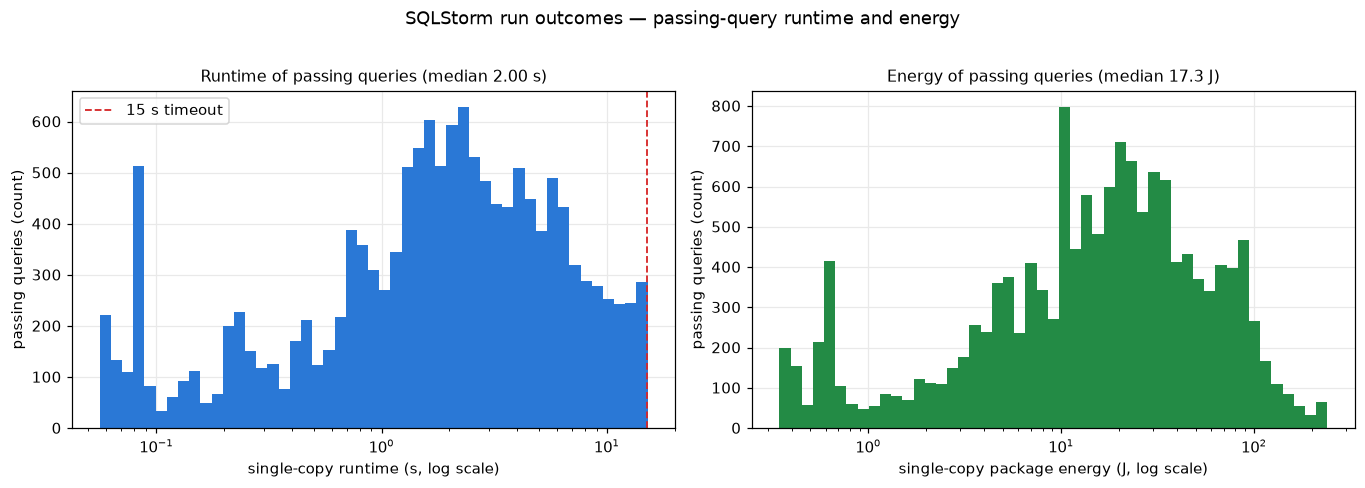

In [7]:
TIMEOUT_S = 14.5        # a failed row at/above this elapsed is a 15 s statement timeout

tim = pd.read_csv(LCACHE / "query_timing_tpch_idx.csv")
for c in ["batchnum", "elapsed_sec", "rapl_pkg_j", "failed"]:
    tim[c] = pd.to_numeric(tim[c], errors="coerce")
tim = tim[tim["phase"] == "measured"].copy()
tim["qid"] = tim["query"].astype(str).str.replace(r"^.*/", "", regex=True).str.replace(r"\.sql$", "", regex=True)
tim["failed"] = tim["failed"].fillna(0).astype(int)
tim["category"] = np.where(tim["failed"] == 0, "ok",
                  np.where(tim["elapsed_sec"] >= TIMEOUT_S, "timeout", "error"))

counts = tim["category"].value_counts()
n_all = len(tim)
print(f"measured queries: {n_all}")
for cat in ["ok", "timeout", "error"]:
    c = int(counts.get(cat, 0))
    print(f"  {cat:8} {c:6}  ({100*c/n_all:.1f}%)")

ok = tim[tim["category"] == "ok"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
a1.hist(ok["elapsed_sec"].clip(lower=1e-3),
        bins=np.logspace(np.log10(max(ok["elapsed_sec"].min(), 1e-3)),
                         np.log10(ok["elapsed_sec"].max()), 50), color="#2a78d6")
a1.axvline(15, color="#d62728", ls="--", lw=1.2, label="15 s timeout")
a1.set_xscale("log"); a1.set_xlabel("single-copy runtime (s, log scale)")
a1.set_ylabel("passing queries (count)"); a1.legend()
a1.set_title(f"Runtime of passing queries (median {ok['elapsed_sec'].median():.2f} s)",
             fontsize=10.5)
pos = ok[ok["rapl_pkg_j"] > 0]["rapl_pkg_j"]
a2.hist(pos, bins=np.logspace(np.log10(pos.min()), np.log10(pos.max()), 50), color="#238b45")
a2.set_xscale("log"); a2.set_xlabel("single-copy package energy (J, log scale)")
a2.set_ylabel("passing queries (count)")
a2.set_title(f"Energy of passing queries (median {pos.median():.1f} J)", fontsize=10.5)
fig.suptitle("SQLStorm run outcomes — passing-query runtime and energy", fontsize=12, y=1.02)
fig.tight_layout(); fig.savefig(FIG / "sqlstorm_runtime_energy.svg", bbox_inches="tight")
plt.show()

## 7. What times out, and the failed/timeout query lists

Timeouts are a complexity signal: the heaviest queries do not finish in 15 s. We show the
timeout rate against structural complexity (tables joined), and the timeout/error split for a
few expensive constructs. Then we **export the query-name lists** requested:
`csv/sqlstorm_failed_queries.csv` (all `failed=1`) and `csv/sqlstorm_timeout_queries.csv` (timeouts).

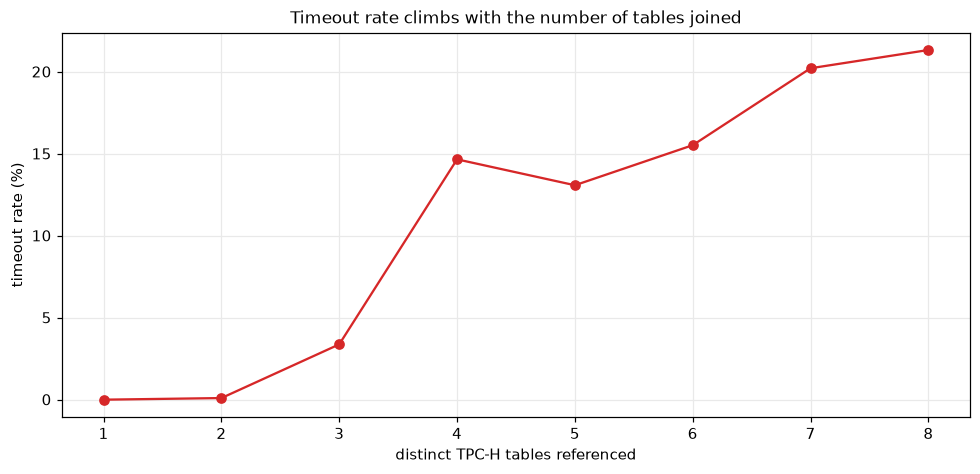

Outcome split by construct (% of queries with that construct):
  CTE (WITH)     n= 9293  timeout 17.9%   error  3.5%
  window (OVER)  n= 7273  timeout 17.4%   error  3.8%
  subquery       n= 9507  timeout 17.7%   error  3.5%
  ALL            n=17036  timeout 13.6%   error  2.0%

wrote csv/sqlstorm_failed_queries.csv  (2656 rows: 2309 timeout + 347 error)
wrote csv/sqlstorm_timeout_queries.csv (2309 rows)

sample failed rows:
  qid                           query  elapsed_sec  rapl_pkg_j  n_tables  n_join category
10041 queries/tpch/SQLStorm/10041.sql    15.068090   90.183655         4       3  timeout
10046 queries/tpch/SQLStorm/10046.sql    15.060649   86.345276         6       5  timeout
10052 queries/tpch/SQLStorm/10052.sql    15.089605   96.160645         3       2  timeout
10053 queries/tpch/SQLStorm/10053.sql    15.101041   90.041565         4       3  timeout
10064 queries/tpch/SQLStorm/10064.sql    15.091156   96.151794         4       3  timeout
10077 queries/tpch/SQLStorm/100

In [8]:
FT = tim.merge(FEAT.reset_index()[["qid", "n_tables", "n_join", "is_cte",
               "has_window", "has_subquery"]], on="qid", how="left")

# timeout rate vs number of tables
by_tab = FT.groupby("n_tables")["category"].apply(lambda s: 100 * (s == "timeout").mean())
cnt_tab = FT.groupby("n_tables").size()
by_tab = by_tab[cnt_tab >= 20]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(by_tab.index, by_tab.values, "-o", color="#d62728", zorder=3)
ax.set_xlabel("distinct TPC-H tables referenced")
ax.set_ylabel("timeout rate (%)")
ax.set_title("Timeout rate climbs with the number of tables joined", fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "sqlstorm_timeout_by_tables.svg", bbox_inches="tight")
plt.show()

# split by construct
print("Outcome split by construct (% of queries with that construct):")
for lbl, col in [("CTE (WITH)", "is_cte"), ("window (OVER)", "has_window"),
                 ("subquery", "has_subquery")]:
    sub = FT[FT[col] == True]
    if len(sub):
        t = 100 * (sub["category"] == "timeout").mean()
        e = 100 * (sub["category"] == "error").mean()
        print(f"  {lbl:14} n={len(sub):5}  timeout {t:4.1f}%   error {e:4.1f}%")
print(f"  {'ALL':14} n={len(FT):5}  timeout "
      f"{100*(FT['category']=='timeout').mean():4.1f}%   "
      f"error {100*(FT['category']=='error').mean():4.1f}%")

# ---- CSV exports ----
cols = ["qid", "query", "elapsed_sec", "rapl_pkg_j", "n_tables", "n_join"]
failed = FT[FT["failed"] == 1][cols + ["category"]].sort_values("qid")
timeout = FT[FT["category"] == "timeout"][cols].sort_values("qid")
failed.to_csv("csv/sqlstorm_failed_queries.csv", index=False)
timeout.to_csv("csv/sqlstorm_timeout_queries.csv", index=False)
print(f"\nwrote csv/sqlstorm_failed_queries.csv  ({len(failed)} rows: "
      f"{int((failed['category']=='timeout').sum())} timeout + "
      f"{int((failed['category']=='error').sum())} error)")
print(f"wrote csv/sqlstorm_timeout_queries.csv ({len(timeout)} rows)")
print("\nsample failed rows:")
print(failed.head(8).to_string(index=False))

## 8. Complexity vs runtime (passing queries)

A final cross-check: among the queries that *do* finish, does structural complexity track
runtime? Median runtime by number of tables joined.

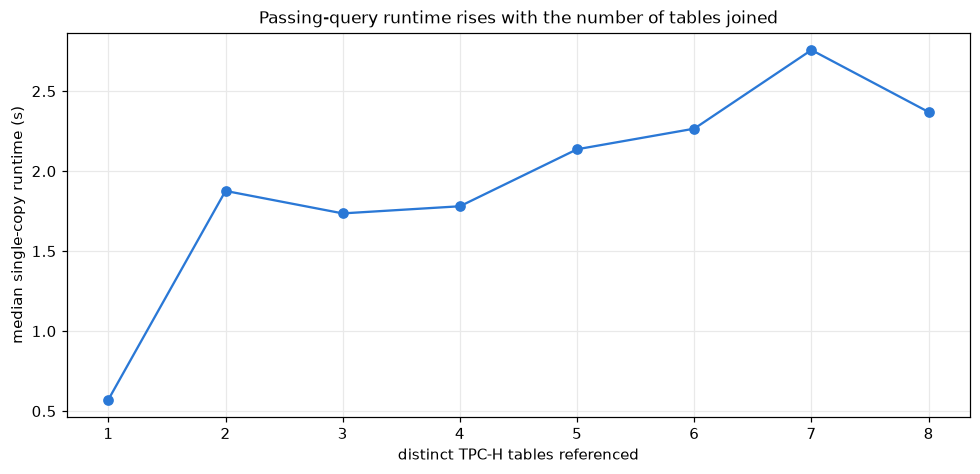

          size  median   mean
n_tables                     
1          662   0.573  0.833
2         1011   1.878  2.061
3         1509   1.738  2.205
4         1496   1.782  2.901
5         2979   2.138  3.322
6         3511   2.267  3.567
7         2077   2.759  4.010
8         1135   2.371  4.032


In [9]:
okft = FT[(FT["category"] == "ok") & (FT["elapsed_sec"] > 0)]
g = okft.groupby("n_tables")["elapsed_sec"]
med = g.median(); n = g.size()
med = med[n >= 20]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(med.index, med.values, "-o", color="#2a78d6", zorder=3)
ax.set_xlabel("distinct TPC-H tables referenced")
ax.set_ylabel("median single-copy runtime (s)")
ax.set_title("Passing-query runtime rises with the number of tables joined", fontsize=11)
fig.tight_layout(); fig.savefig(FIG / "sqlstorm_runtime_by_tables.svg", bbox_inches="tight")
plt.show()
print(okft.groupby("n_tables")["elapsed_sec"]
      .agg(["size", "median", "mean"]).round(3).to_string())

## 9. Summary

* The corpus is **17,036 EXPLAIN-wrapped analytic queries** over the TPC-H schema; the feature
  table (`csv/sqlstorm_query_features.csv`) records clause/join/table/function usage and size per
  query.
* **Frequency:** most queries join multiple tables and aggregate; a meaningful minority use
  CTEs, window functions, subqueries and set operations (see §2, §5).
* **Outcomes:** of the 17,036 single-copy runs at a 2.5 GHz cap with a 15 s statement timeout,
  most pass; the `failed` rows split into **timeouts** (heavy queries that don't finish in 15 s)
  and a smaller set of genuine **errors**. Timeout rate rises with join/table count (§7).
* **Deliverables:** `csv/sqlstorm_failed_queries.csv` (all failures, tagged timeout/error) and
  `csv/sqlstorm_timeout_queries.csv` (timeouts only). The 17k `.sql` files live in
  `cache/sqlstorm_cache/queries/` and are git-ignored.